<center>
    <h1><font color="blue">Exploratory Data Analysis</font></h1>
    <h2>Student Exam Performance Dataset</h2>
</center>

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

In [2]:
# Load the dataset
df = pd.read_csv('../dataset/student_exam_performance_dataset.csv')
print(f"Dataset shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Dataset shape: (10000, 23)
Number of rows: 10000
Number of columns: 23


In [3]:
# Display first few rows
df.head(10)

,student_id,gender,age,parental_education,family_income,internet_access,study_environment,study_hours_per_day,attendance_rate,sleep_hours,...,online_courses_completed,tutoring,math_score,reading_score,writing_score,science_score,final_exam_score,previous_gpa,pass_fail,grade_category
0,S00001,Male,17,High School,Medium,Yes,Quiet,2.98,96.5,6.05,...,1,Yes,42.8,62.4,54.8,51.8,49.1,2.44,Fail,F
1,S00002,Female,18,High School,Low,Yes,Quiet,4.45,95.7,6.96,...,0,Yes,77.9,73.5,64.4,61.6,70.1,2.79,Pass,C
2,S00003,Male,17,High School,Medium,No,Quiet,3.75,76.0,7.02,...,4,Yes,53.5,38.3,36.3,47.1,42.2,1.49,Fail,F
3,S00004,Male,18,Bachelor,Medium,Yes,Quiet,2.03,72.6,6.23,...,4,No,28.3,23.5,32.0,39.0,31.9,1.34,Fail,F
4,S00005,Male,18,Bachelor,Medium,Yes,Quiet,5.14,87.3,8.54,...,0,No,74.7,54.9,73.6,55.5,66.4,2.60,Pass,C
5,S00006,Female,17,Master,Medium,Yes,Quiet,1.16,92.0,8.16,...,2,No,40.3,42.2,44.1,30.0,40.9,1.61,Fail,F
6,S00007,Male,16,High School,High,Yes,Quiet,3.33,74.2,7.34,...,1,No,52.1,48.4,49.4,47.8,47.1,1.35,Fail,F
7,S00008,Male,18,Bachelor,Low,Yes,Moderate,2.01,88.0,6.58,...,4,No,45.6,57.1,47.4,67.0,57.0,2.52,Pass,D
8,S00009,Male,17,Master,Medium,Yes,Moderate,1.22,70.4,7.96,...,2,No,23.9,26.9,32.3,32.8,30.2,1.20,Fail,F
9,S00010,Female,15,Master,Low,Yes,Quiet,1.64,95.6,7.51,...,2,Yes,59.6,46.2,68.0,48.3,54.8,2.02,Pass,D


In [4]:
# Display last few rows
df.tail(5)

,student_id,gender,age,parental_education,family_income,internet_access,study_environment,study_hours_per_day,attendance_rate,sleep_hours,...,online_courses_completed,tutoring,math_score,reading_score,writing_score,science_score,final_exam_score,previous_gpa,pass_fail,grade_category
9995,S09996,Female,15,Master,High,Yes,Moderate,3.80,83.1,7.48,...,1,No,44.2,38.2,38.5,39.0,41.9,1.54,Fail,F
9996,S09997,Male,15,High School,Medium,Yes,Quiet,2.46,68.0,6.76,...,3,No,56.8,46.2,50.6,34.9,47.5,1.49,Fail,F
9997,S09998,Female,15,High School,Low,Yes,Moderate,5.08,76.0,6.90,...,2,No,67.4,50.5,63.7,83.3,64.2,2.38,Pass,D
9998,S09999,Female,18,Bachelor,Medium,Yes,Moderate,1.56,91.0,7.13,...,1,No,35.4,35.5,46.8,47.2,44.3,1.45,Fail,F
9999,S10000,Male,17,High School,Low,Yes,Noisy,3.63,100.0,5.42,...,0,No,66.7,61.6,60.3,60.4,59.6,2.24,Pass,D


In [5]:
# Check data types and info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  10000 non-null  object 
 1   gender                      10000 non-null  object 
 2   age                         10000 non-null  int64  
 3   parental_education          10000 non-null  object 
 4   family_income               10000 non-null  object 
 5   internet_access             10000 non-null  object 
 6   study_environment           10000 non-null  object 
 7   study_hours_per_day         10000 non-null  float64
 8   attendance_rate             10000 non-null  float64
 9   sleep_hours                 10000 non-null  float64
 10  social_media_hours          10000 non-null  float64
 11  assignment_completion_rate  10000 non-null  float64
 12  participation_score         10000 non-null  float64
 13  online_courses_completed    1000

In [6]:
# List all columns
print("Columns in the dataset:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

Columns in the dataset:
 1. student_id
 2. gender
 3. age
 4. parental_education
 5. family_income
 6. internet_access
 7. study_environment
 8. study_hours_per_day
 9. attendance_rate
10. sleep_hours
11. social_media_hours
12. assignment_completion_rate
13. participation_score
14. online_courses_completed
15. tutoring
16. math_score
17. reading_score
18. writing_score
19. science_score
20. final_exam_score
21. previous_gpa
22. pass_fail
23. grade_category


### <font color="blue">2.3 Descriptive Statistics</font>

In [7]:
# Descriptive statistics for numerical columns
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,10000.0,16.486900,1.122744,15.0,15.0000,16.00,17.00,18.00
study_hours_per_day,10000.0,3.019702,1.179235,0.5,2.2000,3.01,3.83,7.24
attendance_rate,10000.0,84.703770,9.509211,50.8,78.2750,85.10,91.90,100.00
sleep_hours,10000.0,7.018894,0.991714,4.0,6.3375,7.03,7.69,10.00
social_media_hours,10000.0,2.517300,1.446750,0.0,1.5000,2.50,3.50,8.00
assignment_completion_rate,10000.0,79.491450,13.763237,40.0,70.2000,80.00,90.00,100.00
participation_score,10000.0,69.816810,14.659270,20.0,59.8000,69.90,80.10,100.00
online_courses_completed,10000.0,2.029300,1.437445,0.0,1.0000,2.00,3.00,9.00
math_score,10000.0,49.503410,13.879156,0.0,40.0000,49.30,58.60,100.00
reading_score,10000.0,49.755600,13.359603,0.0,40.8000,49.60,58.50,100.00


In [8]:
# Descriptive statistics for categorical columns
df.describe(include='object').transpose()

,count,unique,top,freq
student_id,10000,10000,S00001,1
gender,10000,2,Male,5013
parental_education,10000,4,High School,3926
family_income,10000,3,Medium,5068
internet_access,10000,2,Yes,8986
study_environment,10000,3,Quiet,4073
tutoring,10000,2,No,7004
pass_fail,10000,2,Fail,5142
grade_category,10000,5,F,5172


In [9]:
# Number of unique values in each column
print("Number of unique values in each column:")
print(df.nunique())

Number of unique values in each column:
student_id                    10000
gender                            2
age                               4
parental_education                4
family_income                     3
internet_access                   2
study_environment                 3
study_hours_per_day             587
attendance_rate                 444
sleep_hours                     551
social_media_hours               78
assignment_completion_rate      588
participation_score             714
online_courses_completed         10
tutoring                          2
math_score                      774
reading_score                   748
writing_score                   755
science_score                   775
final_exam_score                694
previous_gpa                    340
pass_fail                         2
grade_category                    5
dtype: int64


In [10]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")

Categorical columns: ['student_id', 'gender', 'parental_education', 'family_income', 'internet_access', 'study_environment', 'tutoring', 'pass_fail', 'grade_category']


In [11]:
# Value counts for each categorical column
for col in categorical_cols:
    if col != 'student_id':
        print(f"\n--- {col} ---")
        print(df[col].value_counts())


--- gender ---
gender
Male      5013
Female    4987
Name: count, dtype: int64

--- parental_education ---
parental_education
High School    3926
Bachelor       3502
Master         2047
PhD             525
Name: count, dtype: int64

--- family_income ---
family_income
Medium    5068
Low       2971
High      1961
Name: count, dtype: int64

--- internet_access ---
internet_access
Yes    8986
No     1014
Name: count, dtype: int64

--- study_environment ---
study_environment
Quiet       4073
Moderate    3947
Noisy       1980
Name: count, dtype: int64

--- tutoring ---
tutoring
No     7004
Yes    2996
Name: count, dtype: int64

--- pass_fail ---
pass_fail
Fail    5142
Pass    4858
Name: count, dtype: int64

--- grade_category ---
grade_category
F    5172
D    3829
C     904
B      85
A      10
Name: count, dtype: int64


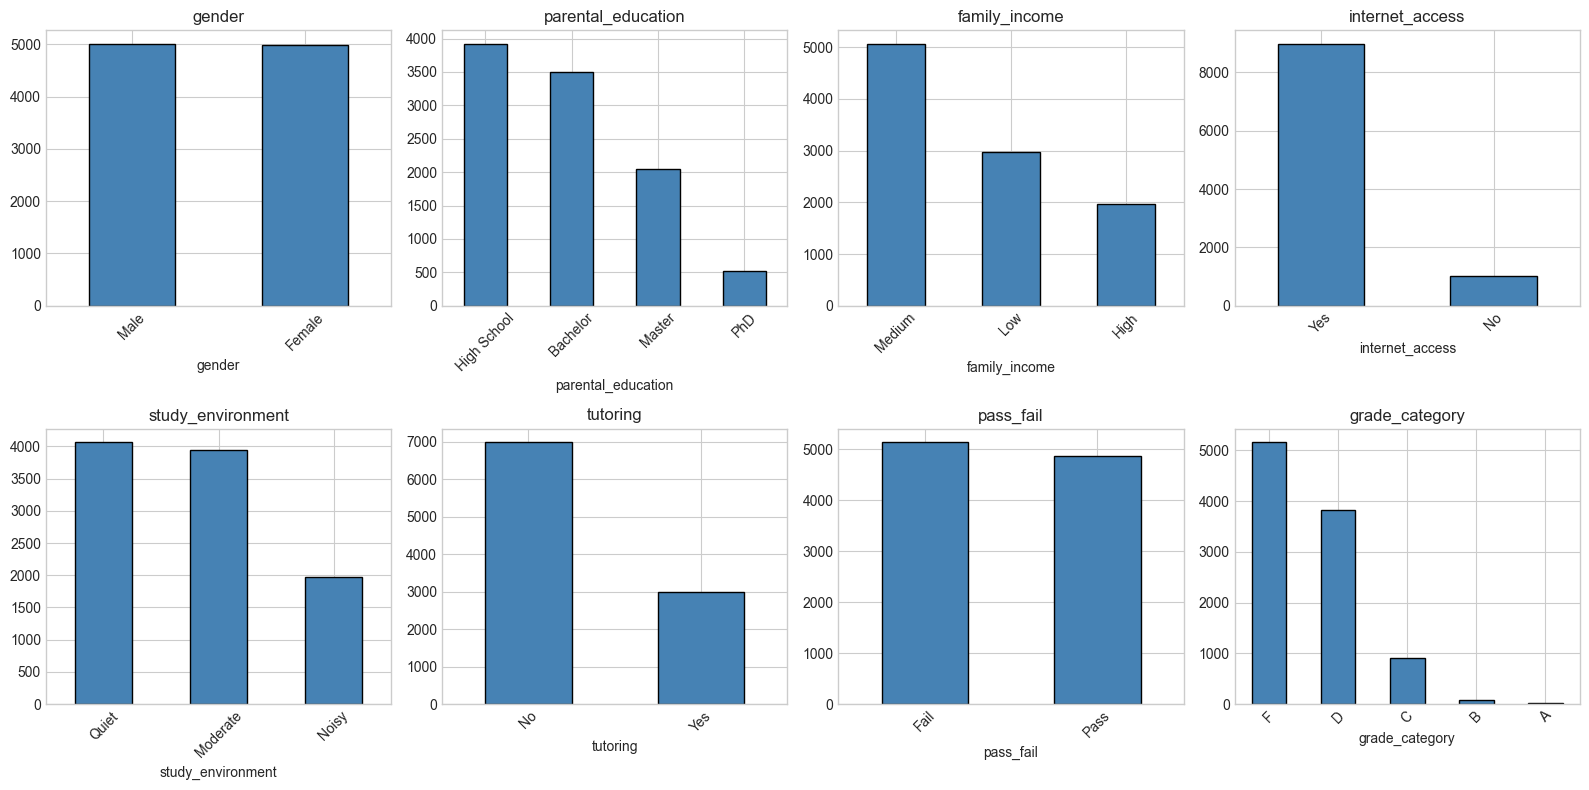

In [12]:
# Visualize categorical distributions
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

cat_cols_to_plot = [col for col in categorical_cols if col != 'student_id']

for i, col in enumerate(cat_cols_to_plot):
    if i < len(axes):
        df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
        axes[i].set_title(col, fontsize=12)
        axes[i].tick_params(axis='x', rotation=45)

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('../docs/categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values found!")

Missing values in each column:
No missing values found!


In [14]:
# Total missing values
total_missing = df.isnull().sum().sum()
print(f"Total missing values in dataset: {total_missing}")

# Percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_table = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': missing_percentage
})
missing_table = missing_table[missing_table['Missing Values'] > 0]

if len(missing_table) > 0:
    print("\nMissing values summary:")
    print(missing_table.sort_values('Percentage', ascending=False))
else:
    print("\nNo missing values in the dataset!")

Total missing values in dataset: 0

No missing values in the dataset!


In [15]:
# Visualize missing values (if any)
if total_missing > 0:
    plt.figure(figsize=(12, 6))
    sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
    plt.title('Missing Values Heatmap')
    plt.show()
else:
    print("No missing values to visualize!")

No missing values to visualize!


In [16]:
# Identify numerical columns (excluding student_id)
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical columns: {numerical_cols}")

Numerical columns: ['age', 'study_hours_per_day', 'attendance_rate', 'sleep_hours', 'social_media_hours', 'assignment_completion_rate', 'participation_score', 'online_courses_completed', 'math_score', 'reading_score', 'writing_score', 'science_score', 'final_exam_score', 'previous_gpa']


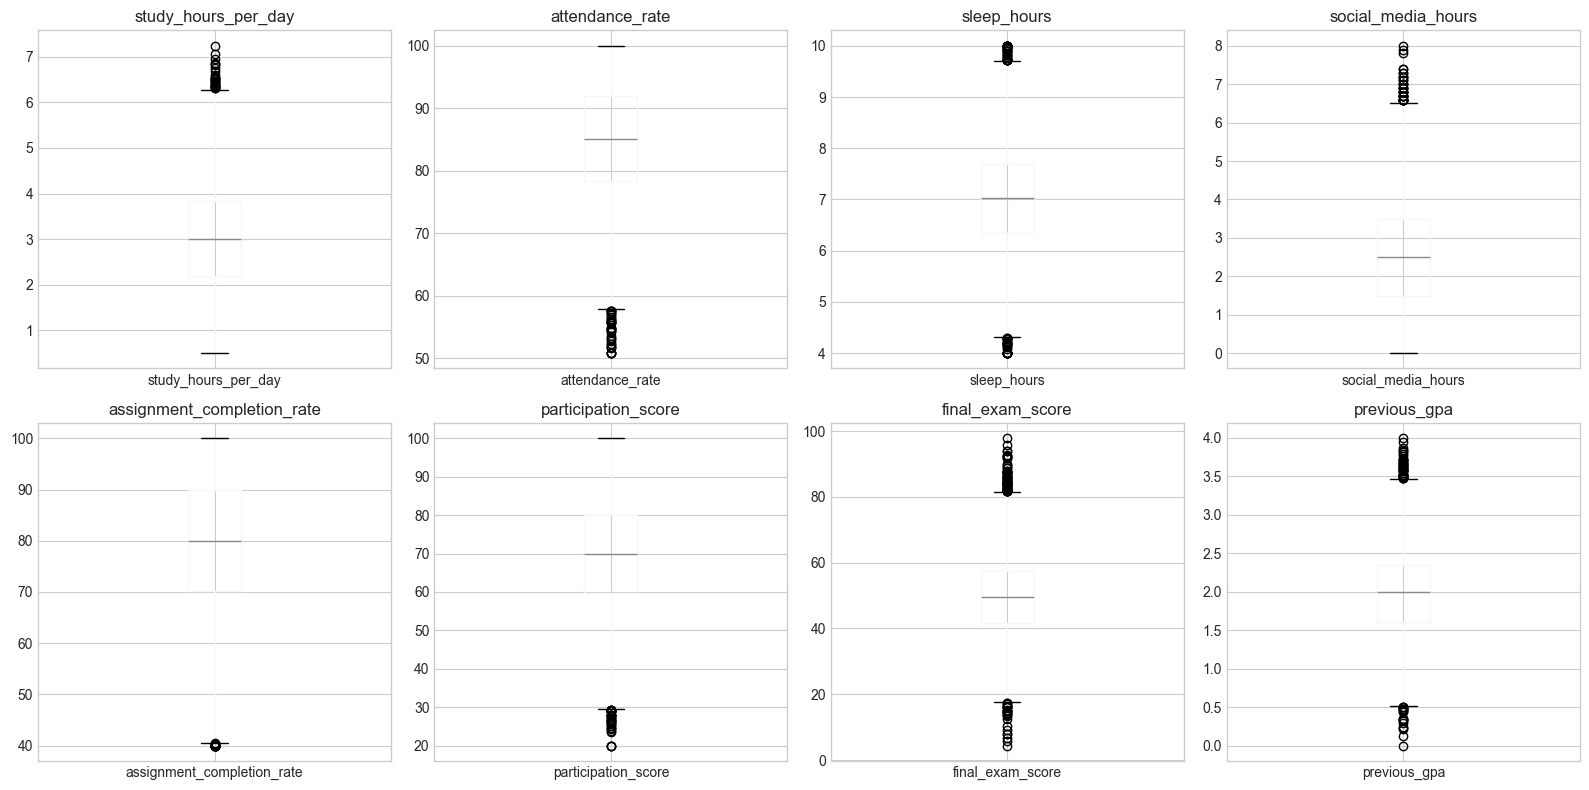

In [17]:
# Boxplots for key numerical features
key_features = ['study_hours_per_day', 'attendance_rate', 'sleep_hours', 'social_media_hours', 
                'assignment_completion_rate', 'participation_score', 'final_exam_score', 'previous_gpa']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(key_features):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.savefig('../docs/boxplots_key_features.png', dpi=150, bbox_inches='tight')
plt.show()

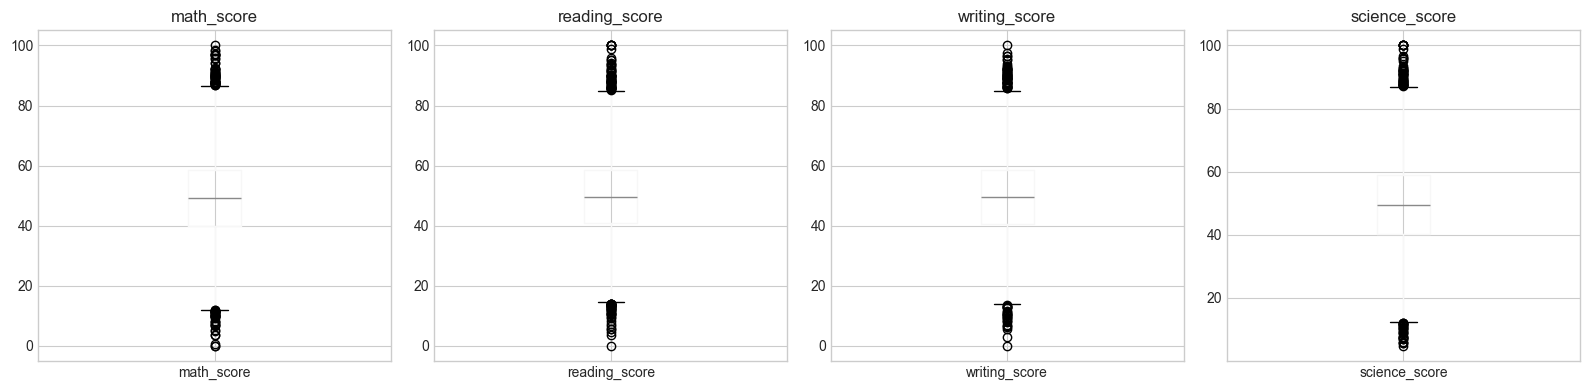

In [18]:
# Boxplots for subject scores
subject_scores = ['math_score', 'reading_score', 'writing_score', 'science_score']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, col in enumerate(subject_scores):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.savefig('../docs/boxplots_subject_scores.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# Calculate IQR and detect outliers
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

print("Outlier Analysis using IQR Method:")
print("="*60)

for col in key_features:
    count, lower, upper = detect_outliers_iqr(df, col)
    print(f"{col:30s} | Outliers: {count:5d} | Bounds: [{lower:.2f}, {upper:.2f}]")

Outlier Analysis using IQR Method:
study_hours_per_day            | Outliers:    27 | Bounds: [-0.24, 6.28]
attendance_rate                | Outliers:    36 | Bounds: [57.84, 112.34]
sleep_hours                    | Outliers:    63 | Bounds: [4.31, 9.72]
social_media_hours             | Outliers:    36 | Bounds: [-1.50, 6.50]
assignment_completion_rate     | Outliers:    30 | Bounds: [40.50, 119.70]
participation_score            | Outliers:    35 | Bounds: [29.35, 110.55]
final_exam_score               | Outliers:    95 | Bounds: [17.60, 81.60]
previous_gpa                   | Outliers:    62 | Bounds: [0.50, 3.46]


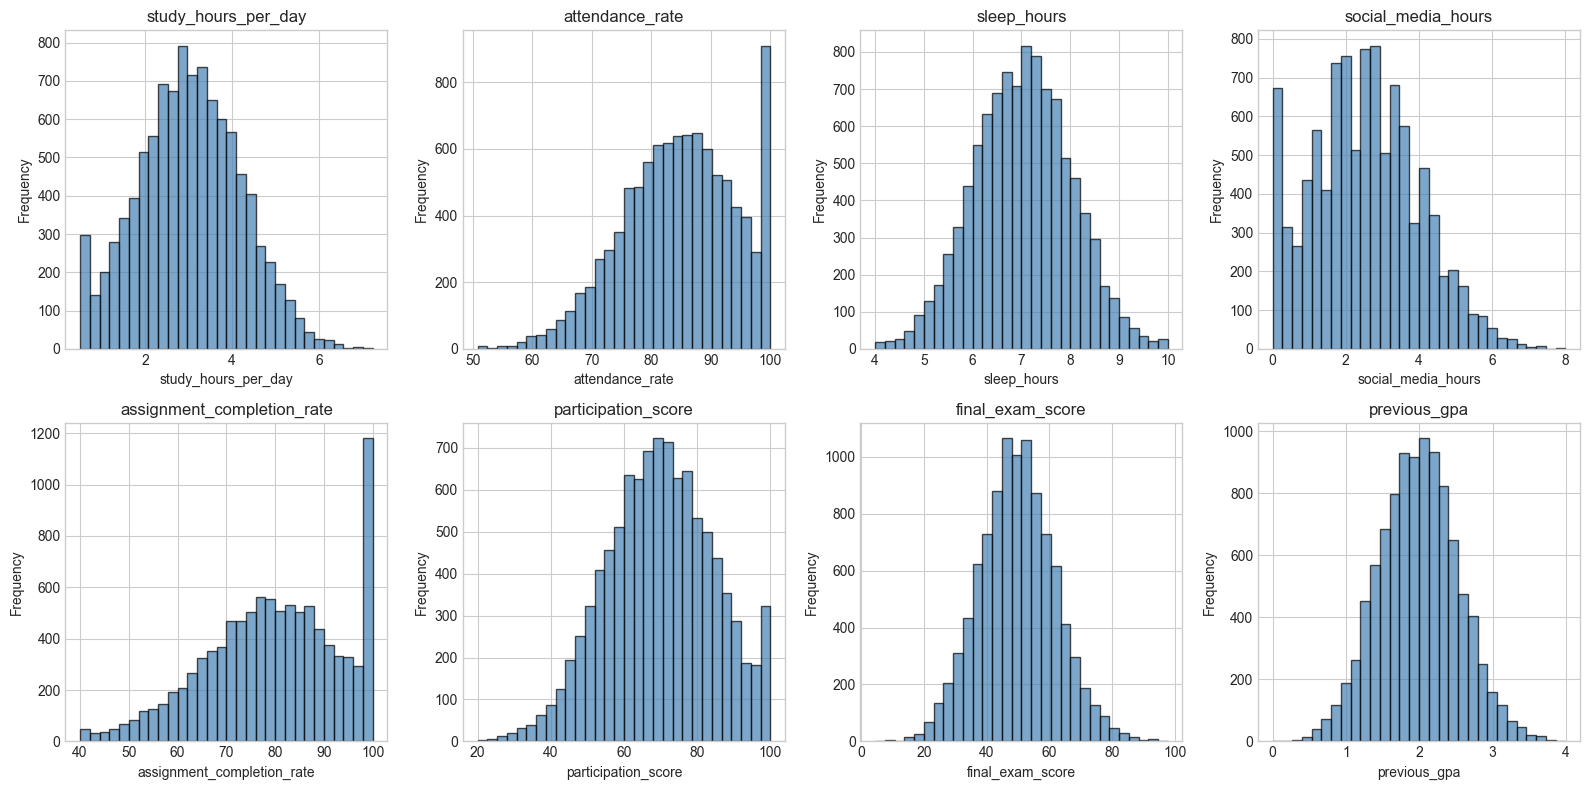

In [20]:
# Histograms for key features
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(key_features):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../docs/histograms_key_features.png', dpi=150, bbox_inches='tight')
plt.show()

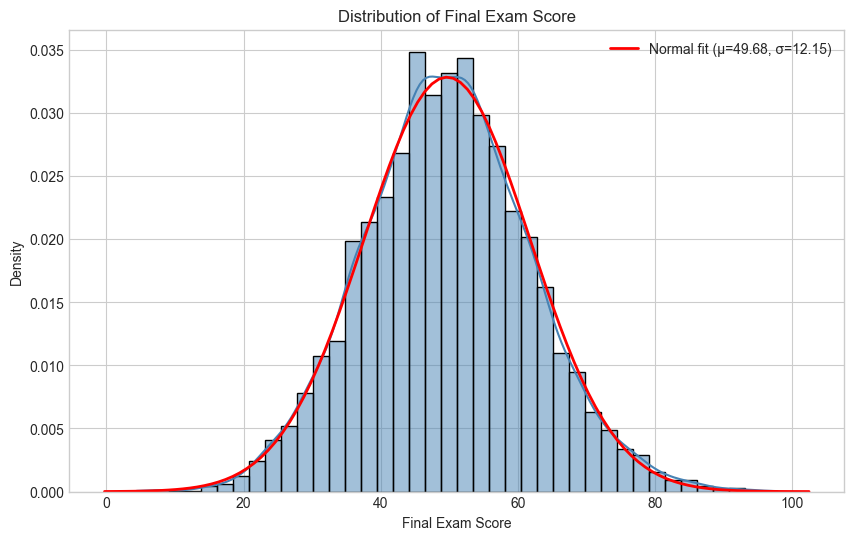

In [21]:
# Histogram with KDE for final_exam_score
plt.figure(figsize=(10, 6))
sns.histplot(df['final_exam_score'], kde=True, stat='density', bins=40, color='steelblue')

# Fit normal distribution
mu, std = norm.fit(df['final_exam_score'])
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'r-', linewidth=2, label=f'Normal fit (μ={mu:.2f}, σ={std:.2f})')

plt.title('Distribution of Final Exam Score')
plt.xlabel('Final Exam Score')
plt.ylabel('Density')
plt.legend()
plt.savefig('../docs/final_exam_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

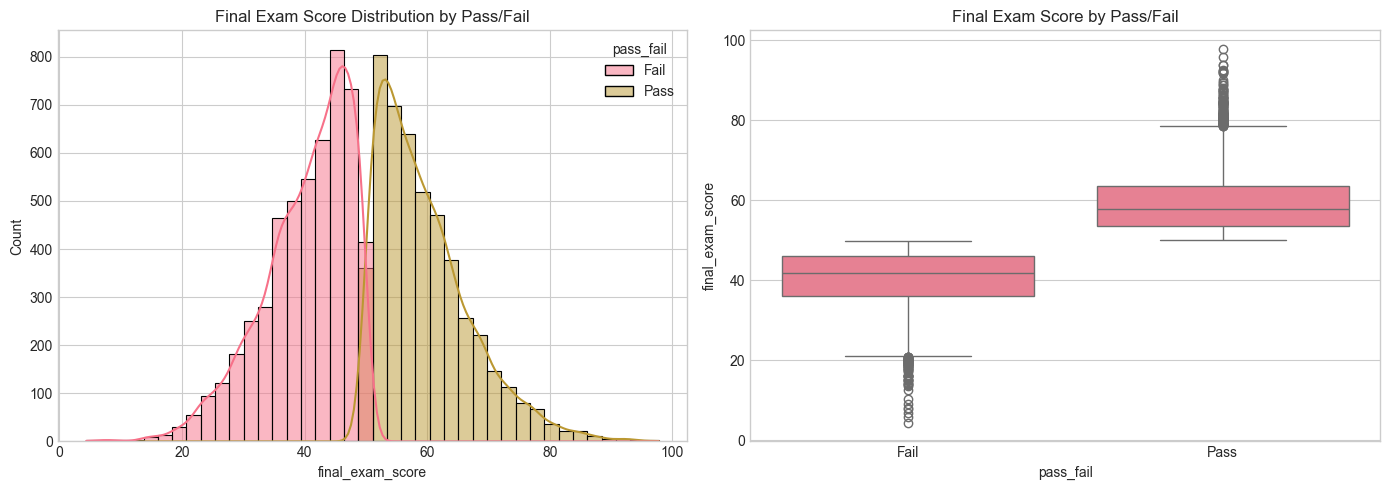

In [22]:
# Distribution by pass/fail
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram by pass/fail
sns.histplot(data=df, x='final_exam_score', hue='pass_fail', kde=True, ax=axes[0], bins=40)
axes[0].set_title('Final Exam Score Distribution by Pass/Fail')

# Boxplot by pass/fail
sns.boxplot(data=df, x='pass_fail', y='final_exam_score', ax=axes[1])
axes[1].set_title('Final Exam Score by Pass/Fail')

plt.tight_layout()
plt.savefig('../docs/final_score_by_passfail.png', dpi=150, bbox_inches='tight')
plt.show()

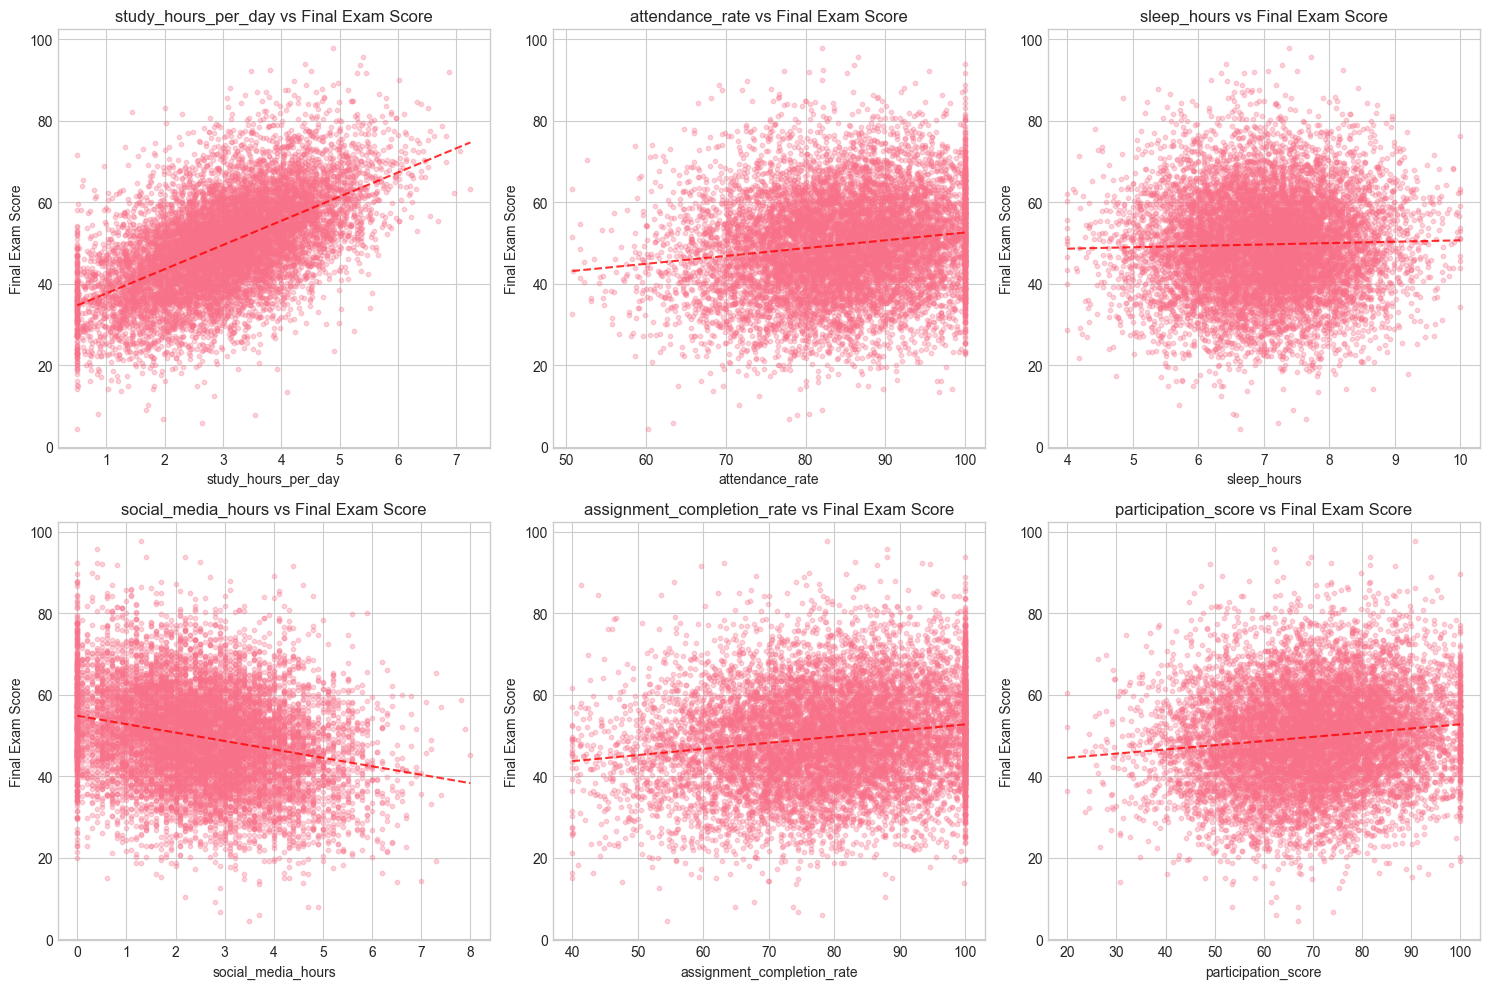

In [23]:
# Scatterplots: Study factors vs Final Exam Score
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

scatter_features = ['study_hours_per_day', 'attendance_rate', 'sleep_hours', 
                   'social_media_hours', 'assignment_completion_rate', 'participation_score']

for i, col in enumerate(scatter_features):
    axes[i].scatter(df[col], df['final_exam_score'], alpha=0.3, s=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Final Exam Score')
    axes[i].set_title(f'{col} vs Final Exam Score')
    
    # Add trend line
    z = np.polyfit(df[col], df['final_exam_score'], 1)
    p = np.poly1d(z)
    axes[i].plot(df[col].sort_values(), p(df[col].sort_values()), "r--", alpha=0.8)

plt.tight_layout()
plt.savefig('../docs/scatterplots_vs_final_score.png', dpi=150, bbox_inches='tight')
plt.show()

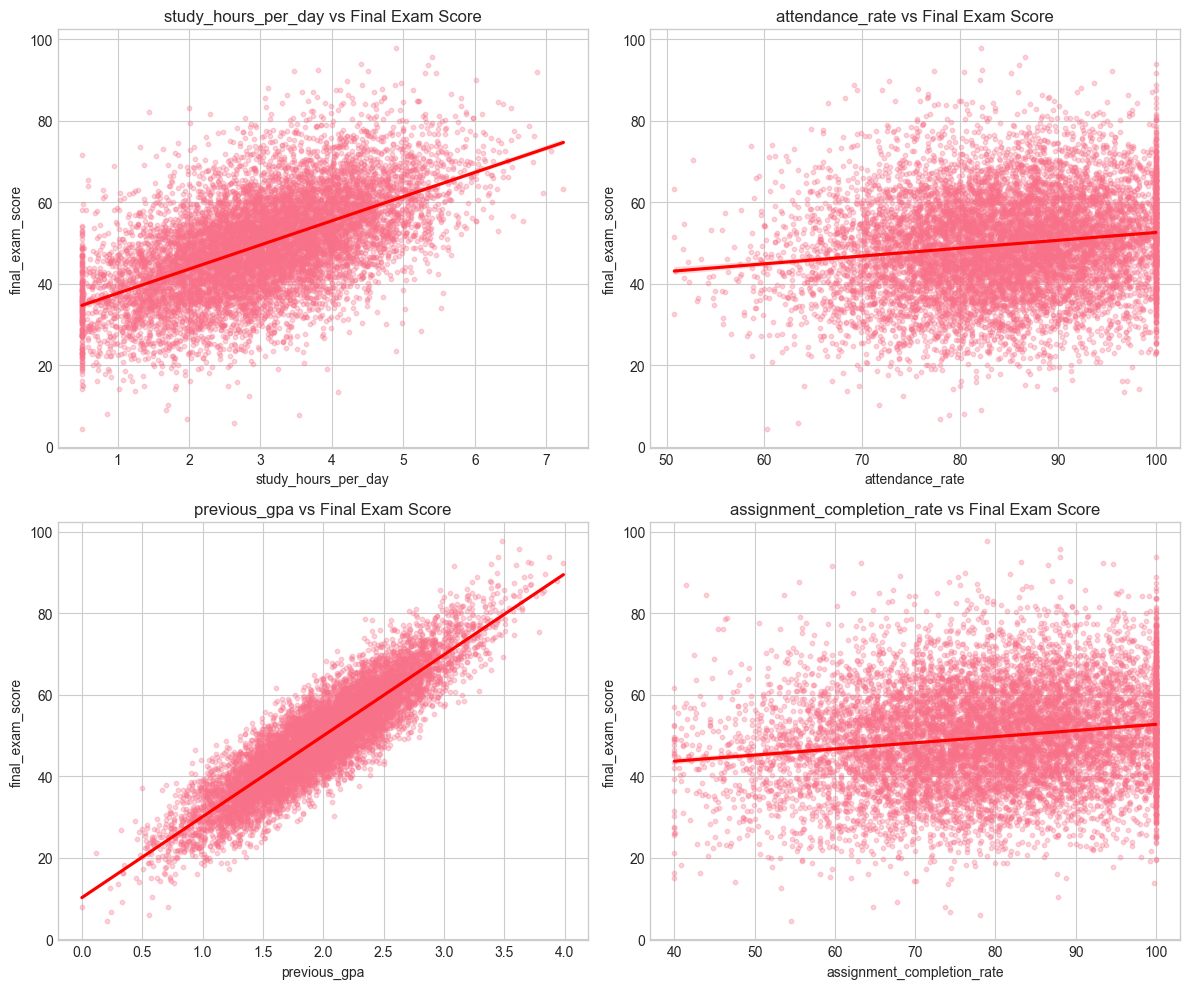

In [24]:
# Scatterplot with regression line using seaborn
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

important_features = ['study_hours_per_day', 'attendance_rate', 'previous_gpa', 'assignment_completion_rate']

for i, col in enumerate(important_features):
    sns.regplot(data=df, x=col, y='final_exam_score', ax=axes[i], 
                scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})
    axes[i].set_title(f'{col} vs Final Exam Score')

plt.tight_layout()
plt.savefig('../docs/regression_plots.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# Calculate correlation matrix for numerical features
numerical_df = df.select_dtypes(include=[np.number])
correlation_matrix = numerical_df.corr()

print("Correlation matrix shape:", correlation_matrix.shape)
correlation_matrix

Correlation matrix shape: (14, 14)


,age,study_hours_per_day,attendance_rate,sleep_hours,social_media_hours,assignment_completion_rate,participation_score,online_courses_completed,math_score,reading_score,writing_score,science_score,final_exam_score,previous_gpa
age,1.000000,-0.004059,0.003528,0.005982,0.024183,0.006663,-0.009924,-0.000165,-0.008944,-0.002440,-0.009198,-0.010729,-0.008198,-0.002145
study_hours_per_day,-0.004059,1.000000,-0.005292,0.010469,0.004751,-0.008913,0.010948,-0.011795,0.502229,0.524930,0.525491,0.502612,0.575822,0.515158
attendance_rate,0.003528,-0.005292,1.000000,-0.001925,0.015274,0.008077,-0.014833,-0.003787,0.133428,0.135038,0.136283,0.135257,0.150618,0.138454
sleep_hours,0.005982,0.010469,-0.001925,1.000000,0.001577,0.004664,0.007446,0.004336,0.014929,0.036950,0.012973,0.031957,0.027876,0.020560
social_media_hours,0.024183,0.004751,0.015274,0.001577,1.000000,-0.030136,-0.001620,-0.007323,-0.221621,-0.220797,-0.218849,-0.217029,-0.246287,-0.219581
assignment_completion_rate,0.006663,-0.008913,0.008077,0.004664,-0.030136,1.000000,-0.005015,0.004944,0.139457,0.152208,0.160892,0.151432,0.170704,0.145326
participation_score,-0.009924,0.010948,-0.014833,0.007446,-0.001620,-0.005015,1.000000,0.007592,0.107751,0.109387,0.107044,0.118446,0.123870,0.107727
online_courses_completed,-0.000165,-0.011795,-0.003787,0.004336,-0.007323,0.004944,0.007592,1.000000,-0.008547,-0.026517,-0.018642,-0.014073,-0.018487,-0.009963
math_score,-0.008944,0.502229,0.133428,0.014929,-0.221621,0.139457,0.107751,-0.008547,1.000000,0.697381,0.704490,0.675318,0.863937,0.769135
reading_score,-0.002440,0.524930,0.135038,0.036950,-0.220797,0.152208,0.109387,-0.026517,0.697381,1.000000,0.725215,0.700841,0.872510,0.779063


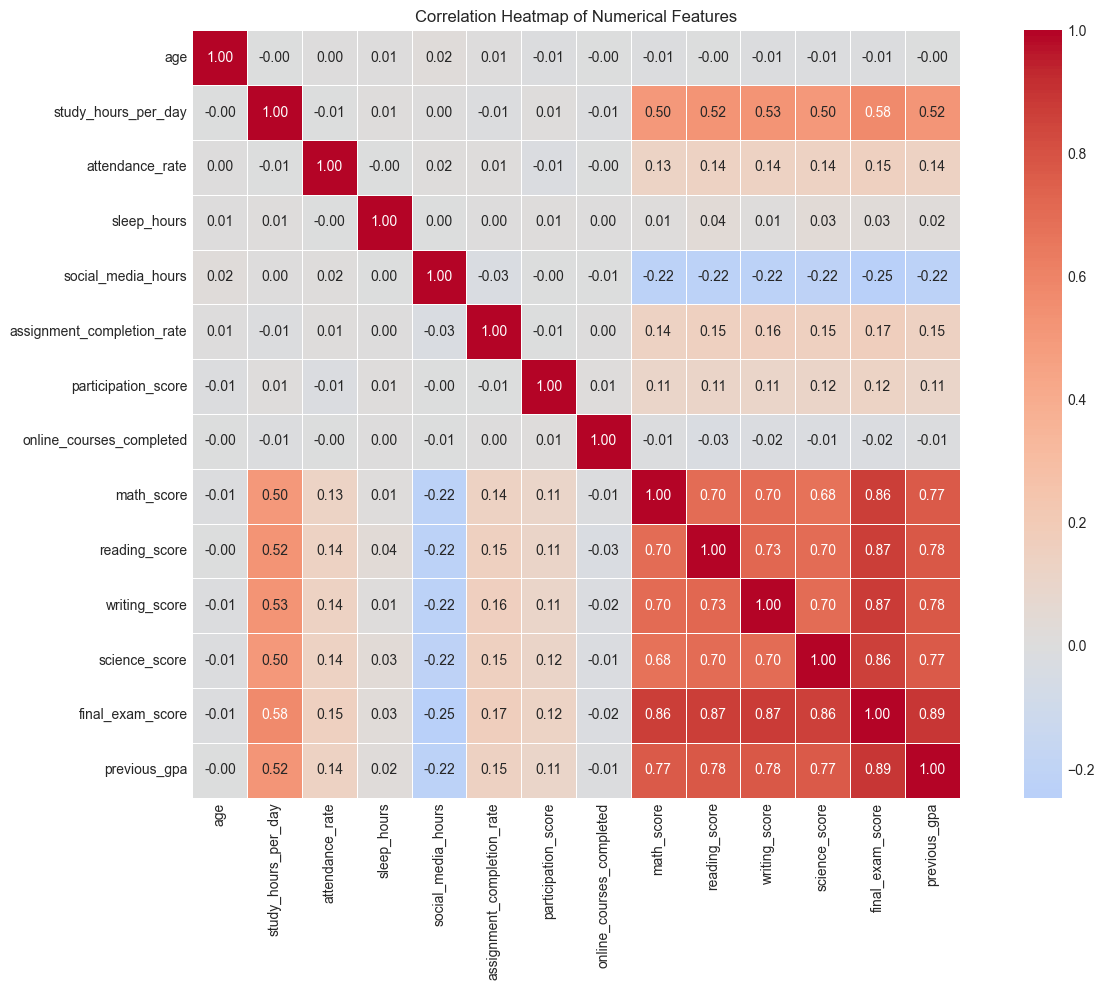

In [26]:
# Heatmap of correlation matrix
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', linewidths=0.5, square=True)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.savefig('../docs/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# Correlation with final_exam_score (sorted)
target_corr = correlation_matrix['final_exam_score'].drop('final_exam_score').sort_values(key=abs, ascending=False)

print("Correlation with Final Exam Score (sorted by absolute value):")
print("="*55)
for feature, corr in target_corr.items():
    print(f"{feature:30s} : {corr:+.4f}")

Correlation with Final Exam Score (sorted by absolute value):
previous_gpa                   : +0.8912
writing_score                  : +0.8745
reading_score                  : +0.8725
math_score                     : +0.8639
science_score                  : +0.8627
study_hours_per_day            : +0.5758
social_media_hours             : -0.2463
assignment_completion_rate     : +0.1707
attendance_rate                : +0.1506
participation_score            : +0.1239
sleep_hours                    : +0.0279
online_courses_completed       : -0.0185
age                            : -0.0082


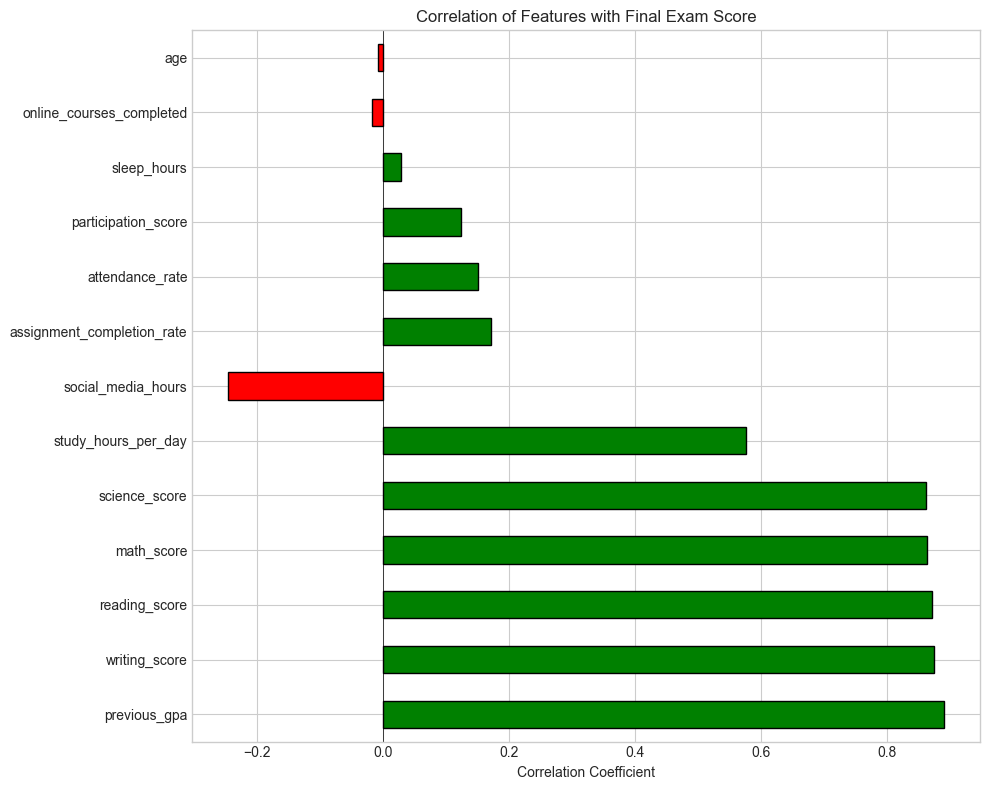

In [28]:
# Bar plot of correlations with final_exam_score
plt.figure(figsize=(10, 8))
colors = ['green' if x > 0 else 'red' for x in target_corr.values]
target_corr.plot(kind='barh', color=colors, edgecolor='black')
plt.xlabel('Correlation Coefficient')
plt.title('Correlation of Features with Final Exam Score')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.savefig('../docs/correlation_with_target.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# Identify strongly correlated features (|correlation| >= 0.5)
strong_correlations = target_corr[abs(target_corr) >= 0.5]
print("\nStrongly correlated features with Final Exam Score (|r| >= 0.5):")
print("="*55)
for feature, corr in strong_correlations.items():
    print(f"{feature:30s} : {corr:+.4f}")


Strongly correlated features with Final Exam Score (|r| >= 0.5):
previous_gpa                   : +0.8912
writing_score                  : +0.8745
reading_score                  : +0.8725
math_score                     : +0.8639
science_score                  : +0.8627
study_hours_per_day            : +0.5758


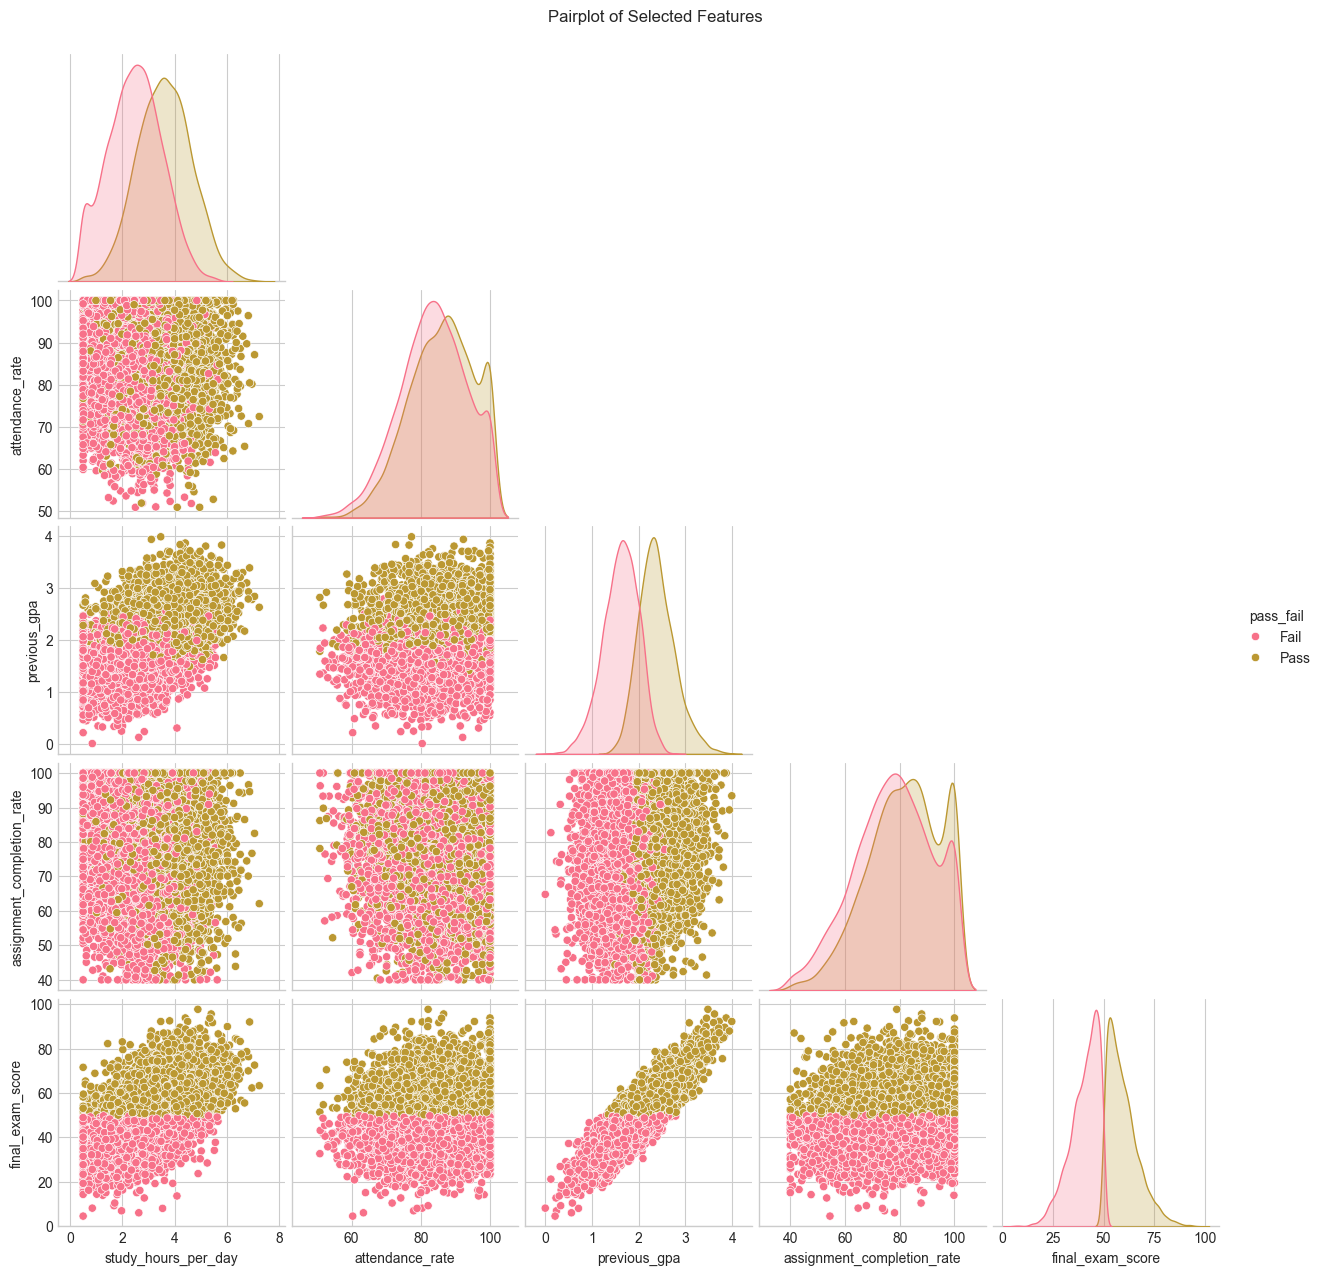

In [30]:
# Pairplot for selected features (subset to avoid overcrowding)
selected_features = ['study_hours_per_day', 'attendance_rate', 'previous_gpa', 
                    'assignment_completion_rate', 'final_exam_score', 'pass_fail']

sns.pairplot(df[selected_features], hue='pass_fail', diag_kind='kde', corner=True)
plt.suptitle('Pairplot of Selected Features', y=1.02)
plt.savefig('../docs/pairplot_selected_features.png', dpi=150, bbox_inches='tight')
plt.show()

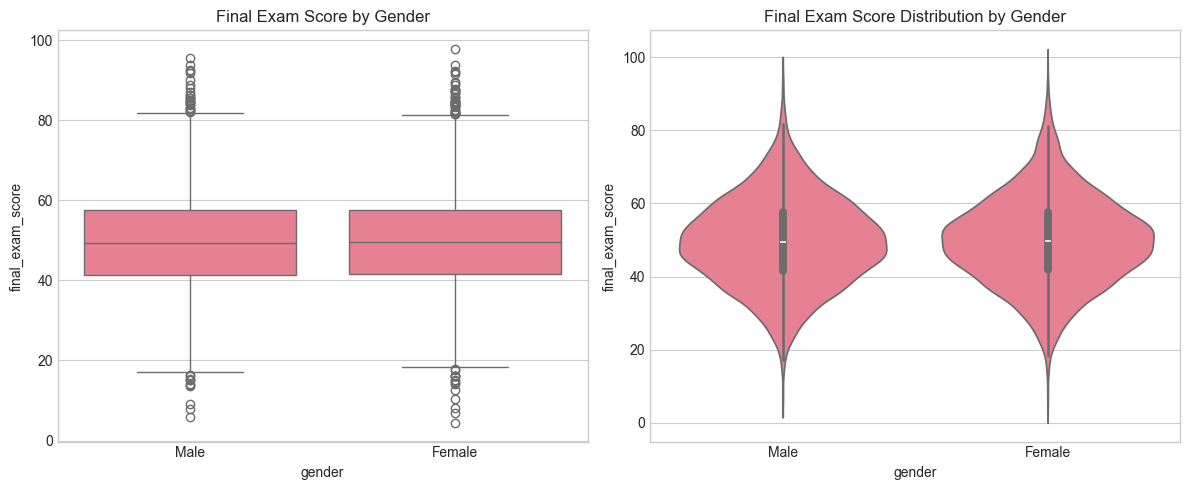


Final Exam Score Statistics by Gender:
         count       mean        std  min   25%   50%   75%   max
gender                                                           
Female  4987.0  49.808582  12.175309  4.4  41.7  49.7  57.6  97.8
Male    5013.0  49.555895  12.124317  5.9  41.4  49.4  57.6  95.7


In [31]:
# Final Exam Score by Gender
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot
sns.boxplot(data=df, x='gender', y='final_exam_score', ax=axes[0])
axes[0].set_title('Final Exam Score by Gender')

# Violin plot
sns.violinplot(data=df, x='gender', y='final_exam_score', ax=axes[1])
axes[1].set_title('Final Exam Score Distribution by Gender')

plt.tight_layout()
plt.show()

# Statistics
print("\nFinal Exam Score Statistics by Gender:")
print(df.groupby('gender')['final_exam_score'].describe())

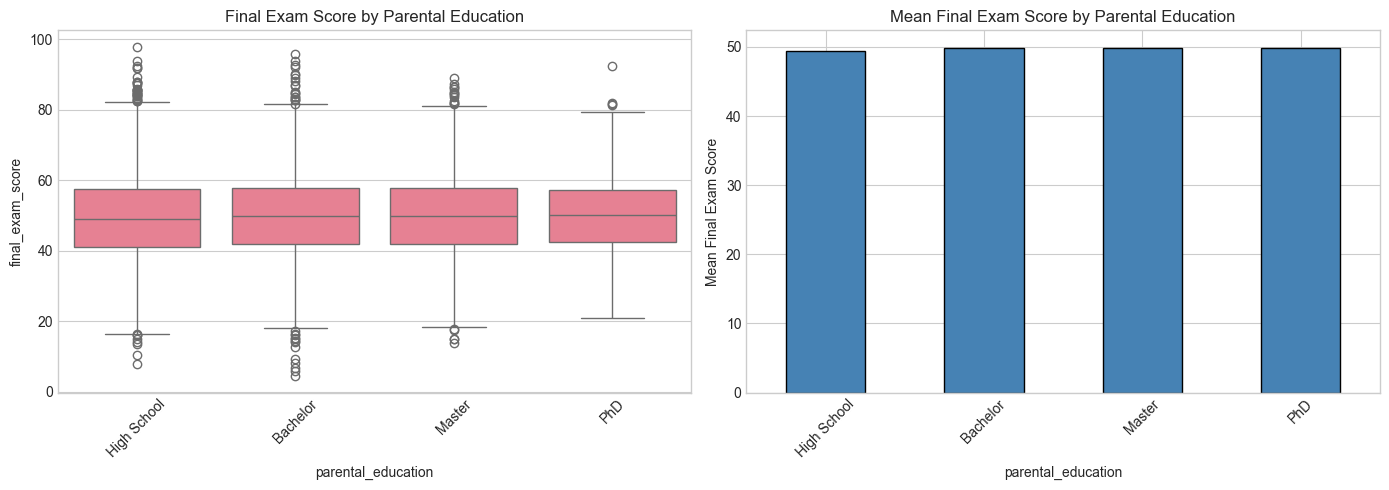


Final Exam Score Statistics by Parental Education:
                     count       mean        std   min     25%   50%   75%  \
parental_education                                                           
Bachelor            3502.0  49.896231  12.171921   4.4  41.900  49.9  57.8   
High School         3926.0  49.424376  12.319969   7.9  40.925  49.1  57.4   
Master              2047.0  49.781241  11.843774  13.8  41.900  49.7  57.7   
PhD                  525.0  49.790857  11.895565  20.8  42.300  50.0  57.1   

                     max  
parental_education        
Bachelor            95.7  
High School         97.8  
Master              88.9  
PhD                 92.3  


In [32]:
# Order for parental education
education_order = ['High School', 'Bachelor', 'Master', 'PhD']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
sns.boxplot(data=df, x='parental_education', y='final_exam_score', order=education_order, ax=axes[0])
axes[0].set_title('Final Exam Score by Parental Education')
axes[0].tick_params(axis='x', rotation=45)

# Bar plot with mean
mean_scores = df.groupby('parental_education')['final_exam_score'].mean().reindex(education_order)
mean_scores.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Mean Final Exam Score by Parental Education')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('Mean Final Exam Score')

plt.tight_layout()
plt.show()

print("\nFinal Exam Score Statistics by Parental Education:")
print(df.groupby('parental_education')['final_exam_score'].describe())

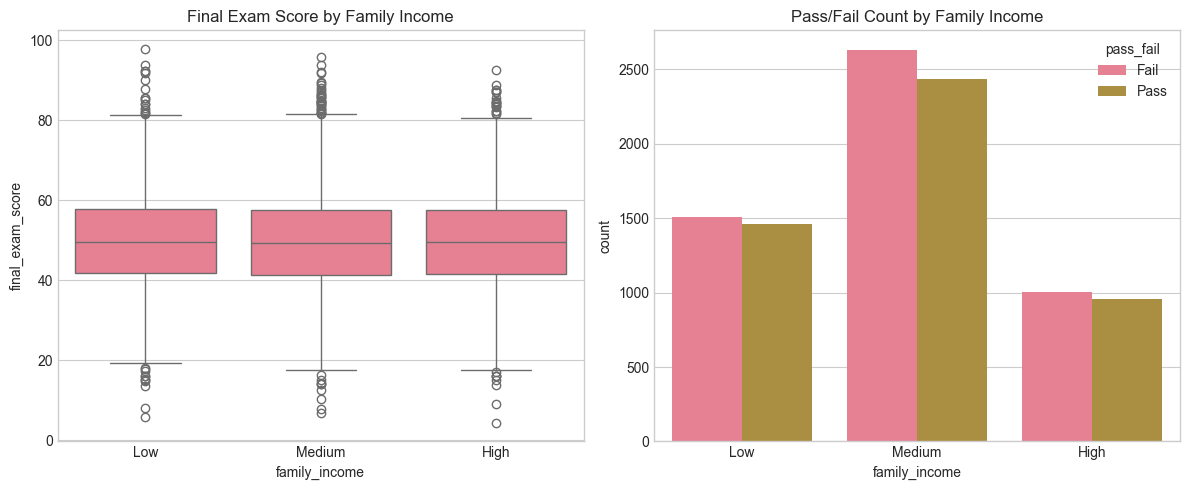

In [33]:
income_order = ['Low', 'Medium', 'High']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot
sns.boxplot(data=df, x='family_income', y='final_exam_score', order=income_order, ax=axes[0])
axes[0].set_title('Final Exam Score by Family Income')

# Count plot for pass/fail by income
sns.countplot(data=df, x='family_income', hue='pass_fail', order=income_order, ax=axes[1])
axes[1].set_title('Pass/Fail Count by Family Income')

plt.tight_layout()
plt.show()

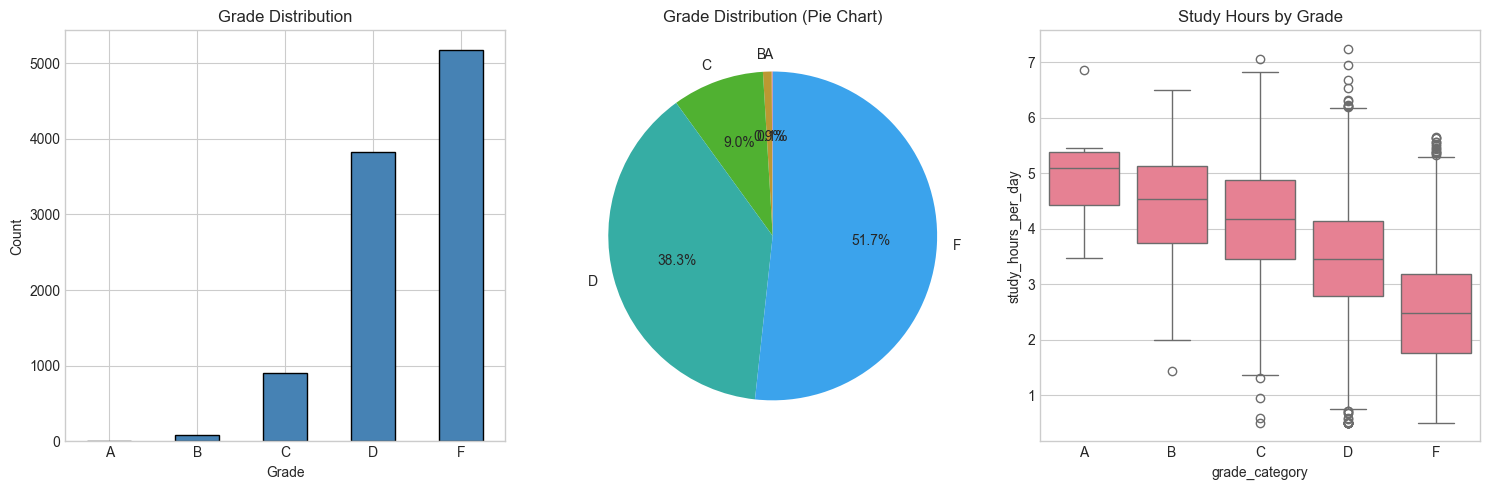


Grade Distribution:
grade_category
A      10
B      85
C     904
D    3829
F    5172
Name: count, dtype: int64


In [34]:
# Grade distribution
grade_order = ['A', 'B', 'C', 'D', 'F']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Count plot
grade_counts = df['grade_category'].value_counts().reindex(grade_order)
grade_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Grade Distribution')
axes[0].set_xlabel('Grade')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
axes[1].pie(grade_counts, labels=grade_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Grade Distribution (Pie Chart)')

# Boxplot of study hours by grade
sns.boxplot(data=df, x='grade_category', y='study_hours_per_day', order=grade_order, ax=axes[2])
axes[2].set_title('Study Hours by Grade')

plt.tight_layout()
plt.savefig('../docs/grade_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nGrade Distribution:")
print(grade_counts)

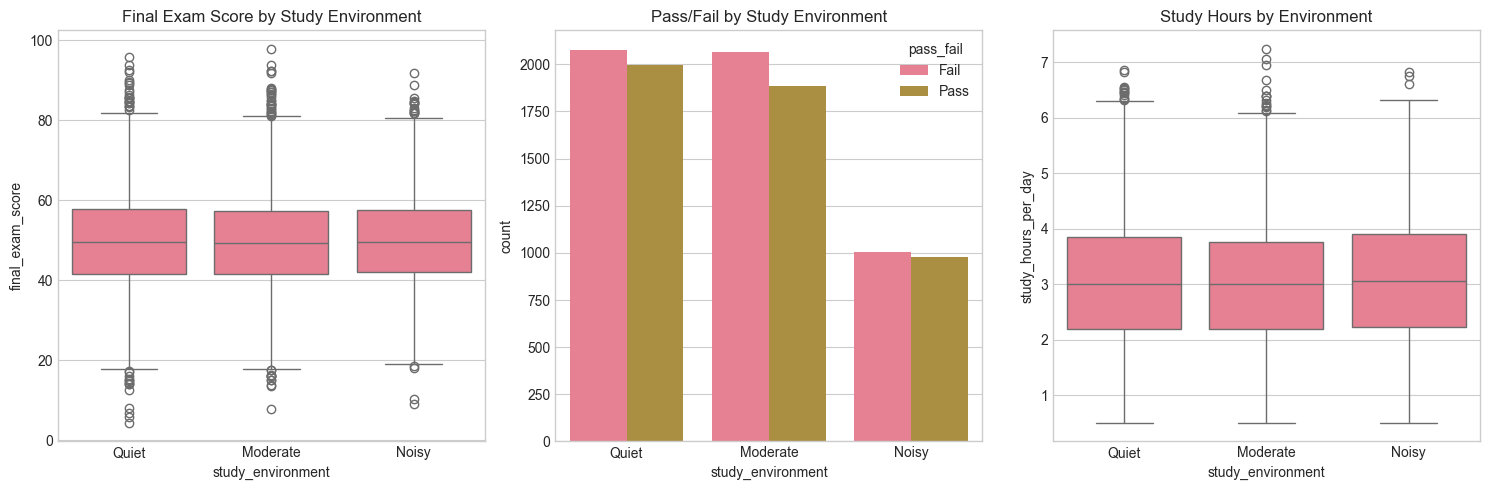

In [35]:
# Study Environment Analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Boxplot
sns.boxplot(data=df, x='study_environment', y='final_exam_score', ax=axes[0])
axes[0].set_title('Final Exam Score by Study Environment')

# Count plot
sns.countplot(data=df, x='study_environment', hue='pass_fail', ax=axes[1])
axes[1].set_title('Pass/Fail by Study Environment')

# Study hours by environment
sns.boxplot(data=df, x='study_environment', y='study_hours_per_day', ax=axes[2])
axes[2].set_title('Study Hours by Environment')

plt.tight_layout()
plt.show()

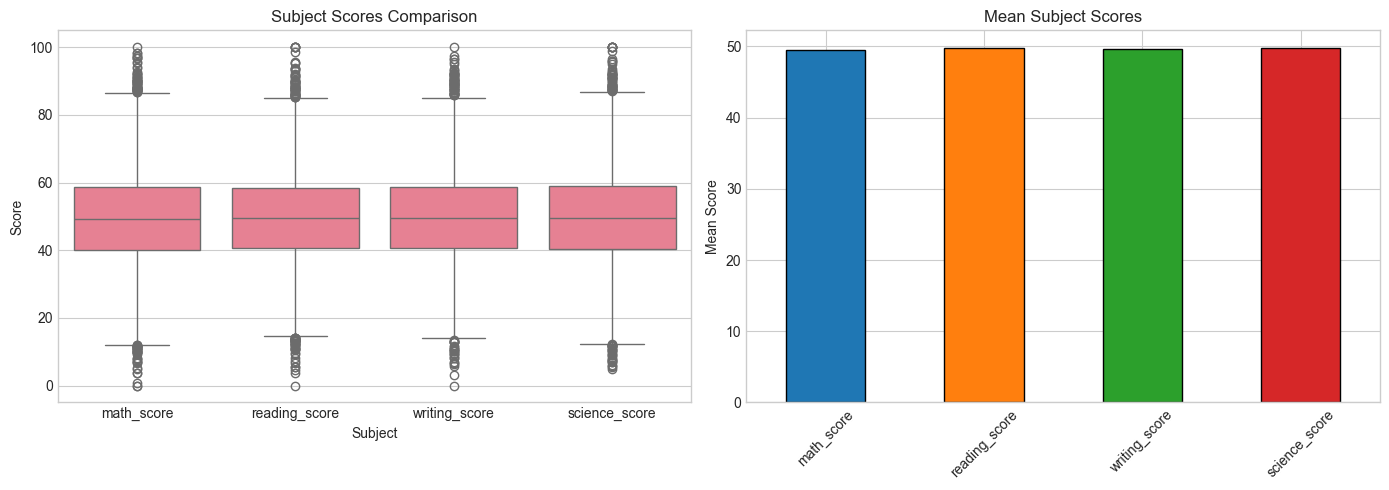


Subject Scores Statistics:
         math_score  reading_score  writing_score  science_score
count  10000.000000   10000.000000   10000.000000   10000.000000
mean      49.503410      49.755600      49.650940      49.759010
std       13.879156      13.359603      13.436917      13.825207
min        0.000000       0.000000       0.000000       4.800000
25%       40.000000      40.800000      40.700000      40.300000
50%       49.300000      49.600000      49.600000      49.600000
75%       58.600000      58.500000      58.600000      59.000000
max      100.000000     100.000000     100.000000     100.000000


In [36]:
# Subject scores comparison
subject_cols = ['math_score', 'reading_score', 'writing_score', 'science_score']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot comparison
df_melted = df[subject_cols].melt(var_name='Subject', value_name='Score')
sns.boxplot(data=df_melted, x='Subject', y='Score', ax=axes[0])
axes[0].set_title('Subject Scores Comparison')

# Mean scores
mean_scores = df[subject_cols].mean()
mean_scores.plot(kind='bar', ax=axes[1], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], edgecolor='black')
axes[1].set_title('Mean Subject Scores')
axes[1].set_ylabel('Mean Score')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\nSubject Scores Statistics:")
print(df[subject_cols].describe())

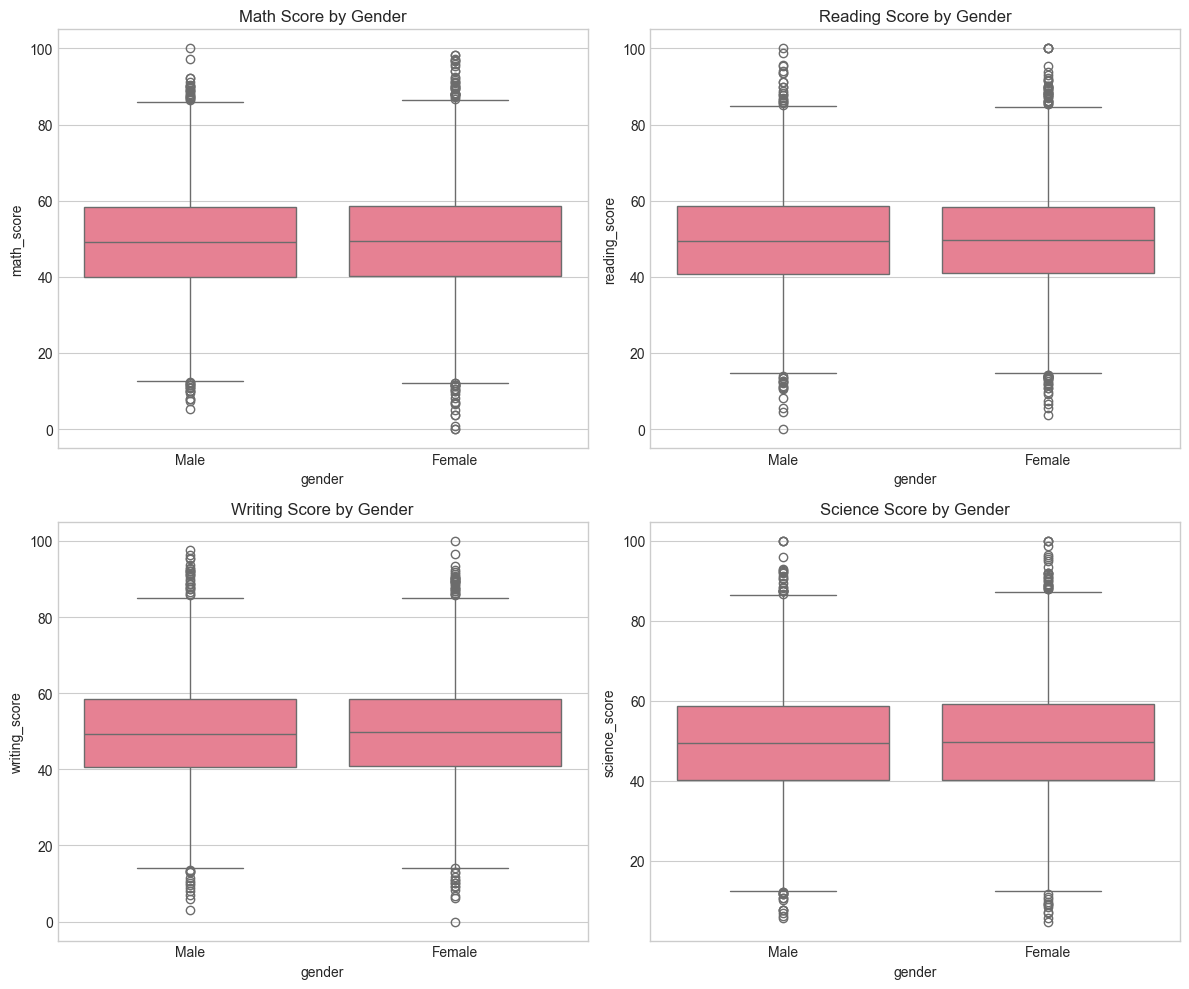

In [37]:
# Subject scores by gender
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, subject in enumerate(subject_cols):
    sns.boxplot(data=df, x='gender', y=subject, ax=axes[i])
    axes[i].set_title(f'{subject.replace("_", " ").title()} by Gender')

plt.tight_layout()
plt.show()

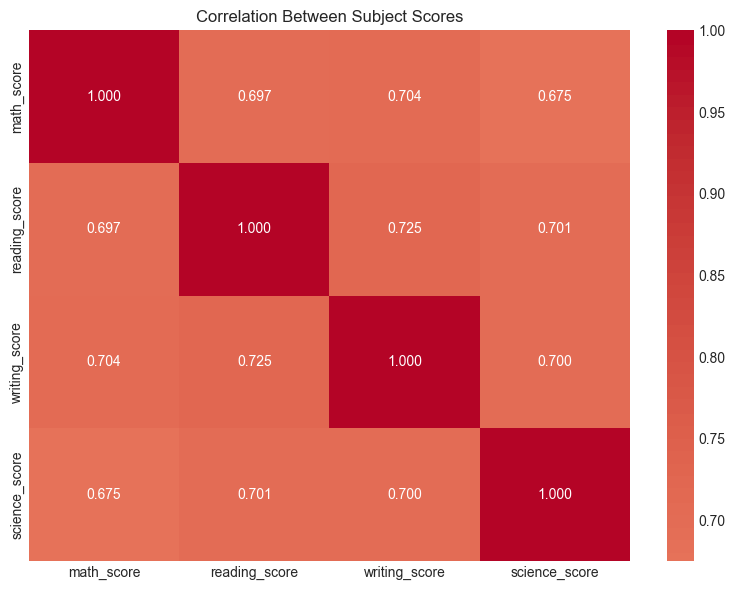

In [38]:
# Correlation between subject scores
subject_corr = df[subject_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(subject_corr, annot=True, cmap='coolwarm', center=0, fmt='.3f')
plt.title('Correlation Between Subject Scores')
plt.tight_layout()
plt.show()

In [39]:
# Summary statistics
print("="*60)
print("EDA SUMMARY FOR STUDENT EXAM PERFORMANCE DATASET")
print("="*60)

print(f"\nDataset Overview:")
print(f"  - Total students: {len(df)}")
print(f"  - Total features: {len(df.columns)}")
print(f"  - Missing values: {df.isnull().sum().sum()}")

print(f"\nTarget Variable - Final Exam Score:")
print(f"  - Mean: {df['final_exam_score'].mean():.2f}")
print(f"  - Std:  {df['final_exam_score'].std():.2f}")
print(f"  - Min:  {df['final_exam_score'].min():.2f}")
print(f"  - Max:  {df['final_exam_score'].max():.2f}")

print(f"\nPass/Fail Distribution:")
pass_fail_counts = df['pass_fail'].value_counts()
for status, count in pass_fail_counts.items():
    print(f"  - {status}: {count} ({count/len(df)*100:.1f}%)")

print(f"\nGrade Distribution:")
grade_counts = df['grade_category'].value_counts().reindex(['A', 'B', 'C', 'D', 'F'])
for grade, count in grade_counts.items():
    print(f"  - {grade}: {count} ({count/len(df)*100:.1f}%)")

print(f"\nTop Correlations with Final Exam Score:")
top_corr = target_corr.head(5)
for feature, corr in top_corr.items():
    print(f"  - {feature}: {corr:+.4f}")

EDA SUMMARY FOR STUDENT EXAM PERFORMANCE DATASET

Dataset Overview:
  - Total students: 10000
  - Total features: 23
  - Missing values: 0

Target Variable - Final Exam Score:
  - Mean: 49.68
  - Std:  12.15
  - Min:  4.40
  - Max:  97.80

Pass/Fail Distribution:
  - Fail: 5142 (51.4%)
  - Pass: 4858 (48.6%)

Grade Distribution:
  - A: 10 (0.1%)
  - B: 85 (0.9%)
  - C: 904 (9.0%)
  - D: 3829 (38.3%)
  - F: 5172 (51.7%)

Top Correlations with Final Exam Score:
  - previous_gpa: +0.8912
  - writing_score: +0.8745
  - reading_score: +0.8725
  - math_score: +0.8639
  - science_score: +0.8627


### Key Findings:

1. **Dataset Quality**: The dataset is clean with no missing values.

2. **Target Variable**: Final exam scores are approximately normally distributed.

3. **Important Features**: The most correlated features with final exam score are likely to be:
   - Previous GPA
   - Study hours per day
   - Assignment completion rate
   - Attendance rate

4. **Grade Distribution**: Most students fall in the middle grade categories (C, D).

5. **Subject Scores**: All four subjects (Math, Reading, Writing, Science) are positively correlated with each other.

6. **Recommendations for Modeling**:
   - Use previous_gpa, study_hours_per_day, and assignment_completion_rate as key predictors
   - Consider feature engineering by combining subject scores
   - Handle potential outliers using IQR method if needed